# Issue #3 — Avaliação: Métricas e Análise do Modelo
Carrega o modelo salvo, gera matriz de confusão, F1-score por classe, feature importance e comparação com baseline.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

sns.set_theme(style='whitegrid')

## 1. Carregar modelo e dados

In [2]:
# Carregar modelo salvo
with open('models/risk_model.pkl', 'rb') as f:
    artefato = pickle.load(f)

modelo = artefato['model']
le     = artefato['label_encoder']
FEATURES = artefato['features']
TARGET   = 'nivel_risco'

print(f"Modelo carregado: {artefato['model_name']}")
print(f"Acurácia CV registrada: {artefato['cv_accuracy_mean']:.4f}")
print(f"Classes: {le.classes_}")

Modelo carregado: Random Forest
Acurácia CV registrada: 0.7737
Classes: ['Alto' 'Baixo' 'Crítico' 'Médio']


In [3]:
# Recriar o mesmo split para avaliação
DB_PATH = '../../sompo.db'
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql('SELECT * FROM telemetria', conn)
conn.close()

df_clean = df[FEATURES + [TARGET]].dropna()
X = df_clean[FEATURES]
y = le.transform(df_clean[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y_pred = modelo.predict(X_test)
print(f'Conjunto de teste: {len(X_test)} registros')

Conjunto de teste: 200 registros


## 2. Matriz de confusão

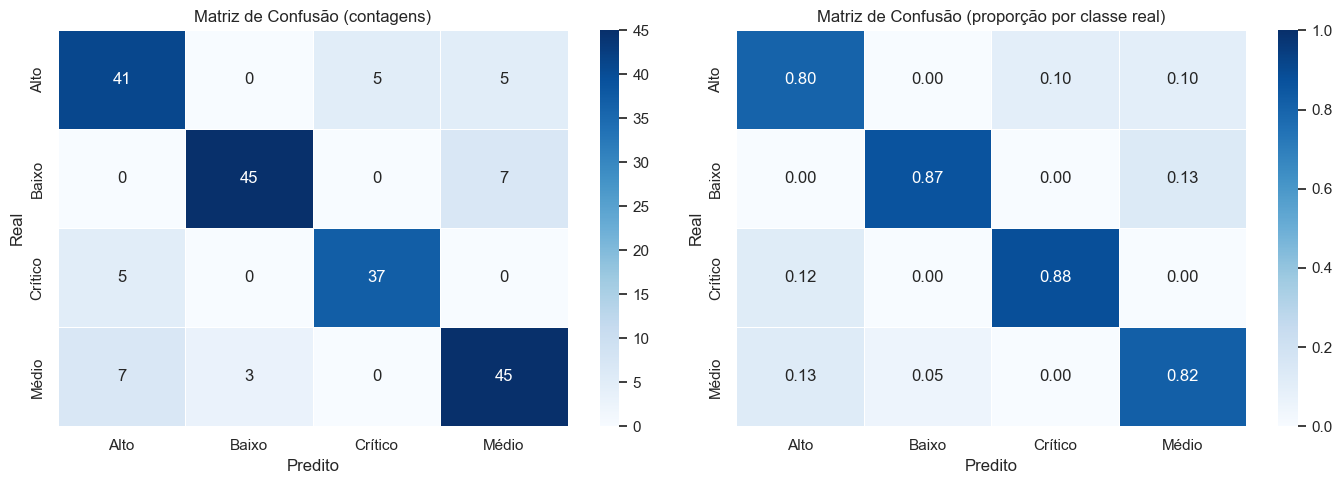

In [4]:
cm = confusion_matrix(y_test, y_pred)
labels = le.classes_

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Contagens absolutas
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax1)
ax1.set_title('Matriz de Confusão (contagens)')
ax1.set_xlabel('Predito')
ax1.set_ylabel('Real')

# Proporção por linha (recall visual)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax2, vmin=0, vmax=1)
ax2.set_title('Matriz de Confusão (proporção por classe real)')
ax2.set_xlabel('Predito')
ax2.set_ylabel('Real')

plt.tight_layout()
plt.savefig('../../assets/ml_matriz_confusao.png', dpi=100, bbox_inches='tight')
plt.show()

## 3. Métricas por classe

In [5]:
acc = accuracy_score(y_test, y_pred)
print(f'Acurácia geral: {acc:.4f} ({acc*100:.2f}%)\n')
print('=== Relatório por classe ===')
print(classification_report(y_test, y_pred, target_names=labels))

Acurácia geral: 0.8400 (84.00%)

=== Relatório por classe ===
              precision    recall  f1-score   support

        Alto       0.77      0.80      0.79        51
       Baixo       0.94      0.87      0.90        52
     Crítico       0.88      0.88      0.88        42
       Médio       0.79      0.82      0.80        55

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



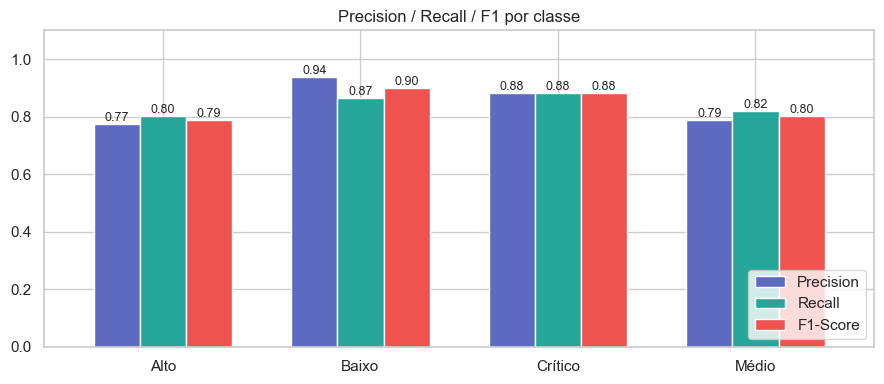

         Precision  Recall  F1-Score
Alto        0.7736  0.8039    0.7885
Baixo       0.9375  0.8654    0.9000
Crítico     0.8810  0.8810    0.8810
Médio       0.7895  0.8182    0.8036


In [6]:
# Visualização das métricas por classe
p = precision_score(y_test, y_pred, average=None)
r = recall_score(y_test, y_pred, average=None)
f = f1_score(y_test, y_pred, average=None)

metricas_df = pd.DataFrame({'Precision': p, 'Recall': r, 'F1-Score': f}, index=labels)

fig, ax = plt.subplots(figsize=(9, 4))
metricas_df.plot(kind='bar', ax=ax, color=['#5C6BC0','#26A69A','#EF5350'],
                 edgecolor='white', width=0.7)
ax.set_title('Precision / Recall / F1 por classe')
ax.set_xlabel('')
ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.tight_layout()
plt.savefig('../../assets/ml_metricas_por_classe.png', dpi=100, bbox_inches='tight')
plt.show()

print(metricas_df.round(4))

## 4. Feature Importance

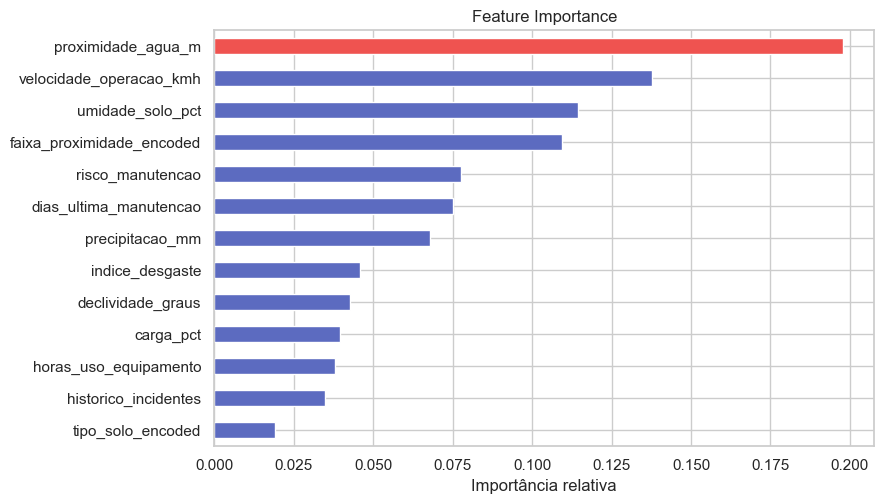


Top 5 features mais importantes:
proximidade_agua_m           0.197706
velocidade_operacao_kmh      0.137772
umidade_solo_pct             0.114476
faixa_proximidade_encoded    0.109520
risco_manutencao             0.077614
dtype: float64


In [7]:
if hasattr(modelo, 'feature_importances_'):
    imp = pd.Series(modelo.feature_importances_, index=FEATURES)
    imp = imp.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, max(4, len(FEATURES)*0.4)))
    cores = ['#EF5350' if v == imp.max() else '#5C6BC0' for v in imp.values]
    imp.plot(kind='barh', ax=ax, color=cores, edgecolor='white')
    ax.set_title('Feature Importance')
    ax.set_xlabel('Importância relativa')
    plt.tight_layout()
    plt.savefig('../../assets/ml_feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()

    print('\nTop 5 features mais importantes:')
    print(imp.sort_values(ascending=False).head())
else:
    print('Modelo não tem feature_importances_ (Logistic Regression).')
    print('Use coef_ para ver os pesos por classe.')

## 5. Comparação Modelo Final vs Baseline

               Acurácia  F1 Macro
Baseline           0.49    0.4533
Random Forest      0.84    0.8432


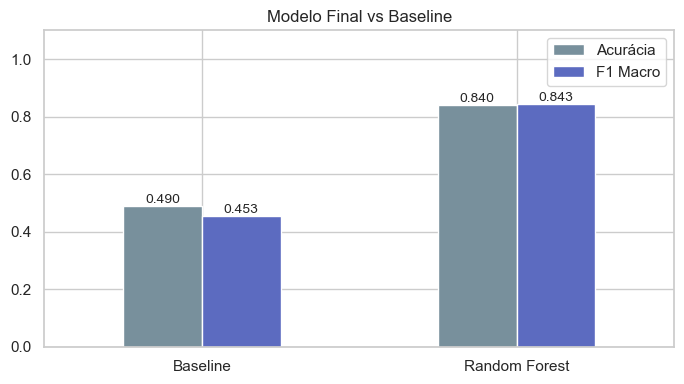

In [8]:
def baseline_predict(X, le):
    classes = le.classes_.tolist()
    preds = []
    for _, row in X.iterrows():
        dist = row.get('proximidade_agua_m', 999)
        if dist < 50: label = 'Crítico'
        elif dist < 200: label = 'Alto'
        elif dist < 500: label = 'Médio'
        else: label = 'Baixo'
        preds.append(le.transform([label])[0] if label in classes else 0)
    return np.array(preds)

y_baseline = baseline_predict(X_test, le)
acc_baseline = accuracy_score(y_test, y_baseline)
f1_baseline = f1_score(y_test, y_baseline, average='macro')
f1_modelo = f1_score(y_test, y_pred, average='macro')

comp = pd.DataFrame({
    'Acurácia': [acc_baseline, acc],
    'F1 Macro': [f1_baseline, f1_modelo]
}, index=['Baseline', artefato['model_name']])

print(comp.round(4))

ax = comp.plot(kind='bar', figsize=(7, 4), color=['#78909C','#5C6BC0'],
               edgecolor='white', ylim=(0,1.1))
ax.set_title('Modelo Final vs Baseline')
ax.tick_params(axis='x', rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=10)
plt.tight_layout()
plt.savefig('../../assets/ml_baseline_vs_modelo.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Gerar relatorio_metricas.md automaticamente

In [9]:
report_lines = [
    '# Relatório de Métricas — Issue #3\n',
    f'**Modelo escolhido:** {artefato["model_name"]}  \n',
    f'**Acurácia (CV k=5):** {artefato["cv_accuracy_mean"]:.4f}  \n',
    f'**Acurácia (teste):** {acc:.4f}  \n',
    f'**F1 Macro (teste):** {f1_modelo:.4f}  \n\n',
    '## Métricas por Classe\n\n',
    '| Classe | Precision | Recall | F1-Score |\n',
    '|--------|-----------|--------|----------|\n',
]
for cls, pi, ri, fi in zip(labels, p, r, f):
    report_lines.append(f'| {cls} | {pi:.4f} | {ri:.4f} | {fi:.4f} |\n')

report_lines += [
    '\n## Comparação com Baseline\n\n',
    '| Métrica | Baseline | Modelo |\n',
    '|---------|----------|--------|\n',
    f'| Acurácia | {acc_baseline:.4f} | {acc:.4f} |\n',
    f'| F1 Macro | {f1_baseline:.4f} | {f1_modelo:.4f} |\n',
    '\n## Imagens\n\n',
    '- ![Matriz de Confusão](../../assets/ml_matriz_confusao.png)\n',
    '- ![Métricas por Classe](../../assets/ml_metricas_por_classe.png)\n',
    '- ![Feature Importance](../../assets/ml_feature_importance.png)\n',
]

with open('relatorio_metricas.md', 'w', encoding='utf-8') as f_out:
    f_out.writelines(report_lines)

print('relatorio_metricas.md gerado!')

relatorio_metricas.md gerado!
